## End to End Sale predection notebook

This project follows a complete, small-scale data-science lifecycle using advertising investment as the input and sales as the target.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
DATA_PATH = Path('advertising.csv')
RANDOM_STATE = 42

### Optional Kaggle download

```python
import kagglehub
path = kagglehub.dataset_download('tawfikelmetwally/advertising-dataset')
print(path)
```

The local CSV is the default source for a self-contained GitHub repository.

In [2]:
df = pd.read_csv(DATA_PATH)
print('Shape:', df.shape)
display(df.head())

Shape: (200, 5)


,ID,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


### 1. Data Quality & Descriptive Statistics

In [3]:
display(df.info())
print('\nMissing values:')
display(df.isna().sum().to_frame('missing'))
print('\nDuplicates:', df.duplicated().sum())
display(df.describe().T.round(2))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         200 non-null    int64  
 1   TV         200 non-null    float64
 2   Radio      200 non-null    float64
 3   Newspaper  200 non-null    float64
 4   Sales      200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


None


Missing values:


,missing
ID,0
TV,0
Radio,0
Newspaper,0
Sales,0



Duplicates: 0


,count,mean,std,min,25%,50%,75%,max
ID,200.0,100.50,57.88,1.0,50.75,100.50,150.25,200.0
TV,200.0,147.04,85.85,0.7,74.38,149.75,218.82,296.4
Radio,200.0,23.26,14.85,0.0,9.98,22.90,36.52,49.6
Newspaper,200.0,30.55,21.78,0.3,12.75,25.75,45.10,114.0
Sales,200.0,14.02,5.22,1.6,10.38,12.90,17.40,27.0


### 2. Exploratory Data Analysis

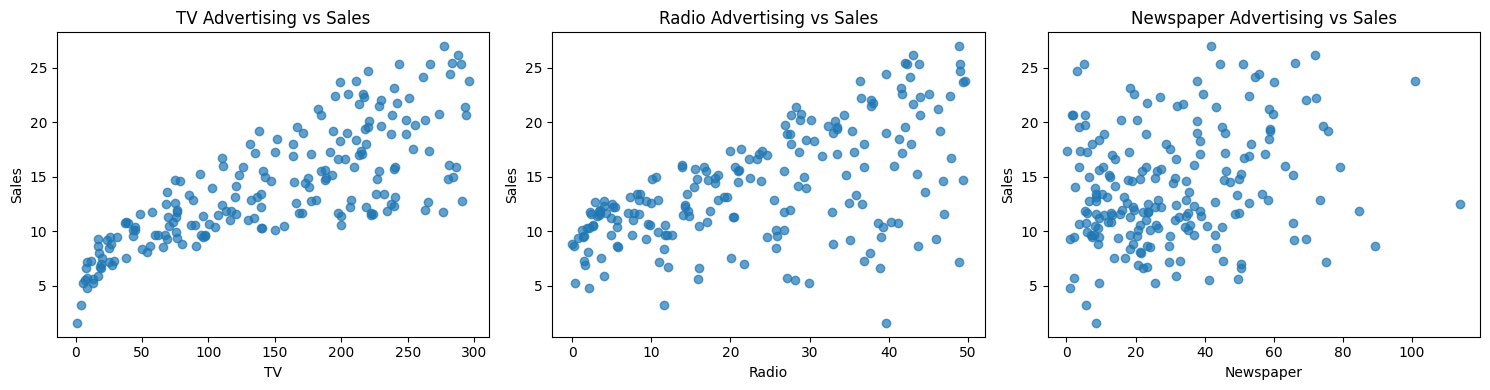

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['TV', 'Radio', 'Newspaper']):
    ax.scatter(df[col], df['Sales'], alpha=0.7)
    ax.set_title(f'{col} Advertising vs Sales')
    ax.set_xlabel(col)
    ax.set_ylabel('Sales')
plt.tight_layout()
plt.show()

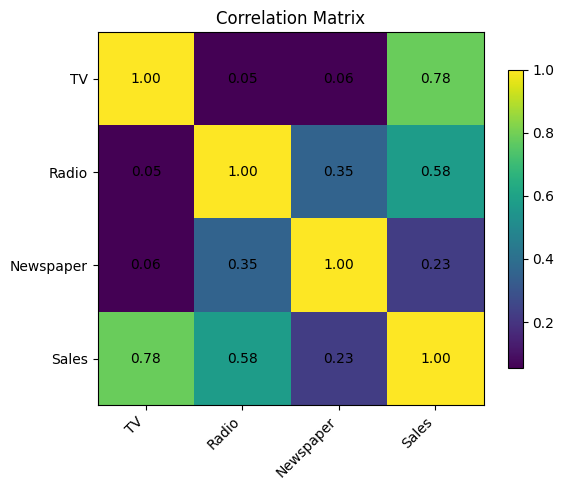

In [5]:
corr = df[['TV', 'Radio', 'Newspaper', 'Sales']].corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, aspect='auto')
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.columns)), corr.columns)
ax.set_title('Correlation Matrix')
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

### 3. Define Features and Target

`Sales` is the target we want to predict. The three advertising channels are input features.

In [6]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print('Training rows:', len(X_train))
print('Testing rows :', len(X_test))

Training rows: 160
Testing rows : 40


### 4. Establish a Baseline

A model should beat something simple. Here the baseline predicts the training-set mean for every test row.

In [7]:
baseline = DummyRegressor(strategy='mean')
baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': rmse,
        'R2': r2_score(y_true, y_pred)
    }

print(regression_metrics(y_test, baseline_pred))

{'MAE': 4.9625, 'RMSE': np.float64(5.631496248777939), 'R2': -0.004757260886999015}


### 5. Train Multiple Models

Linear Regression gives us an interpretable baseline. Random Forest and Gradient Boosting capture nonlinear relationships that a straight-line model may miss.

In [8]:
models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=6, min_samples_leaf=2, random_state=RANDOM_STATE
    ),
    'Gradient Boosting': GradientBoostingRegressor(random_state=RANDOM_STATE)
}

rows = []
trained = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    metrics = regression_metrics(y_test, pred)
    rows.append({'Model': name, **metrics})
    trained[name] = model

model_results = pd.DataFrame(rows).sort_values('RMSE')
display(model_results.round(3))

,Model,MAE,RMSE,R2
2,Gradient Boosting,0.619,0.730,0.983
1,Random Forest,0.673,0.808,0.979
0,Linear Regression,1.461,1.782,0.899


### 6. Cross-Validation

Cross-validation checks whether the model looks stable across several train/validation splits.

In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, model in trained.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    rmse_scores = -scores
    cv_rows.append({
        'Model': name,
        'Mean CV RMSE': rmse_scores.mean(),
        'Std CV RMSE': rmse_scores.std()
    })

cv_results = pd.DataFrame(cv_rows).sort_values('Mean CV RMSE')
display(cv_results.round(3))

,Model,Mean CV RMSE,Std CV RMSE
2,Gradient Boosting,0.727,0.136
1,Random Forest,0.756,0.146
0,Linear Regression,1.706,0.236


### 7. Error Analysis

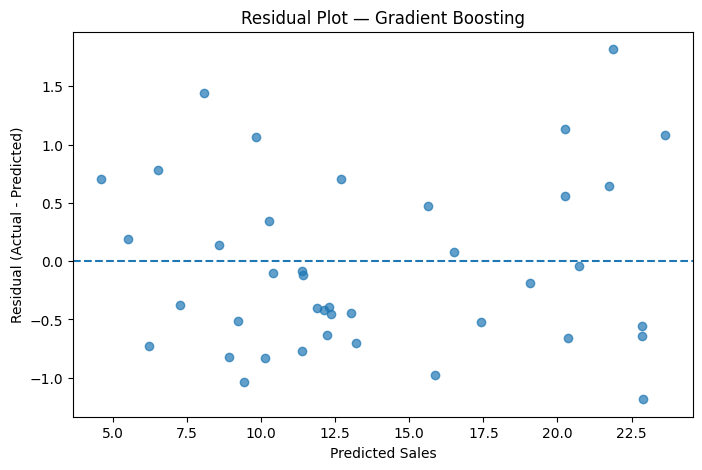

Best model: Gradient Boosting
Metrics: {'MAE': 0.619, 'RMSE': np.float64(0.73), 'R2': 0.983}


In [10]:
best_name = model_results.iloc[0]['Model']
best_model = trained[best_name]
best_pred = best_model.predict(X_test)
residuals = y_test - best_pred
plt.figure(figsize=(8, 5))
plt.scatter(best_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle='--')
plt.title(f'Residual Plot — {best_name}')
plt.xlabel('Predicted Sales')
plt.ylabel('Residual (Actual - Predicted)')
plt.show()

print('Best model:', best_name)
print('Metrics:', {k: round(v, 3) for k, v in regression_metrics(y_test, best_pred).items()})

### 8. Feature Importance / Coefficients

,importance
TV,0.612579
Radio,0.380914
Newspaper,0.006507


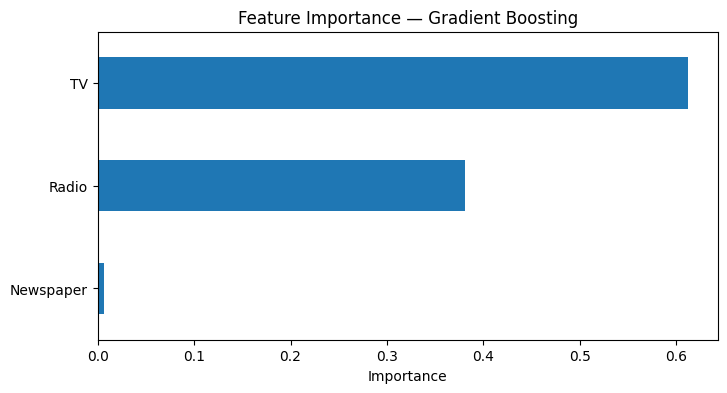

In [11]:
if best_name == 'Linear Regression':
    coefs = best_model.named_steps['model'].coef_
    importance = pd.Series(coefs, index=X.columns).sort_values(key=np.abs, ascending=False)
    display(importance.to_frame('coefficient'))
    importance.sort_values().plot(kind='barh', figsize=(8, 4))
    plt.title('Linear Regression Coefficients')
    plt.xlabel('Coefficient')
    plt.show()
else:
    if hasattr(best_model, 'feature_importances_'):
        importance = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
        display(importance.to_frame('importance'))
        importance.sort_values().plot(kind='barh', figsize=(8, 4))
        plt.title(f'Feature Importance — {best_name}')
        plt.xlabel('Importance')
        plt.show()

### 9. Scenario Prediction Function

This small utility turns the trained model into something a non-technical stakeholder can understand: enter proposed advertising spend and receive a predicted sales value.

In [12]:
def predict_sales(tv: float, radio: float, newspaper: float) -> float:
    row = pd.DataFrame([{
        'TV': tv, 'Radio': radio, 'Newspaper': newspaper
    }])
    return float(best_model.predict(row)[0])

example = predict_sales(tv=200, radio=30, newspaper=20)
print(f'Example predicted sales: {example:.2f}')

Example predicted sales: 18.20
